<a href="https://colab.research.google.com/github/kondapallijayasri739-glitch/student-peformance-prediction/blob/main/House_price_estimator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Housing.csv to Housing.csv


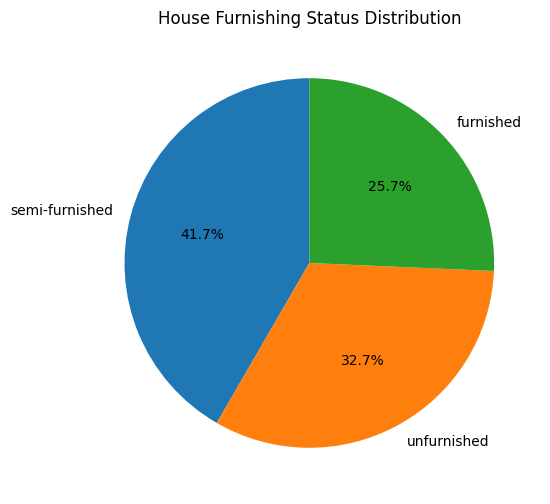

R2 Score: 0.6494754192267803
Mean Absolute Error: 979679.6912959901
Predicted House Price: 8397232.190265846


In [ ]:
# Upload the dataset
from google.colab import files
uploaded = files.upload()

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Read dataset
df = pd.read_csv("Housing.csv")

# Pie chart before converting values
furnishing_count = df['furnishingstatus'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    furnishing_count,
    labels=furnishing_count.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("House Furnishing Status Distribution")
plt.show()

# Convert Yes/No columns to numbers
cols = ['mainroad', 'guestroom', 'basement',
        'hotwaterheating', 'airconditioning', 'prefarea']

for col in cols:
    df[col] = df[col].map({'yes':1, 'no':0})

# Convert furnishing status
df['furnishingstatus'] = df['furnishingstatus'].map({
    'furnished':2,
    'semi-furnished':1,
    'unfurnished':0
})

# Separate features and target
X = df.drop('price', axis=1)
y = df['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Model evaluation
print("R2 Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

# Predict new house price
new_house = pd.DataFrame([{
    'area':7420,
    'bedrooms':4,
    'bathrooms':2,
    'stories':3,
    'mainroad':1,
    'guestroom':0,
    'basement':1,
    'hotwaterheating':0,
    'airconditioning':1,
    'parking':2,
    'prefarea':1,
    'furnishingstatus':2
}])

price = model.predict(new_house)

print("Predicted House Price:", price[0])